# 24. 两两交换链表中的节点

给你一个链表，两两交换其中相邻的节点，并返回交换后链表的头节点。你必须在不修改节点内部的值的情况下完成本题（即，只能进行节点交换）。

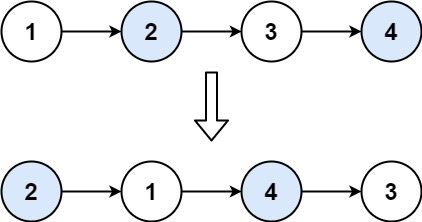

## 迭代法

交换next指针即可，需要注意的是不要断链！

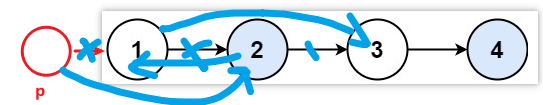

In [ ]:
# Definition for singly-linked list.
# class ListNode:
#     def __init__(self, val=0, next=None):
#         self.val = val
#         self.next = next
class Solution:
    def swapPairs(self, head: Optional[ListNode]) -> Optional[ListNode]:
        dummy_head = ListNode(next=head)
        p = dummy_head
        while p and p.next and p.next.next:
            t = p.next
            p.next = p.next.next
            t.next = p.next.next
            p.next.next = t
            p = p.next.next
        return dummy_head.next
        

### 优化

上面是我写的💩山代码，写的时候出了好几次错，能过，但是不好，下面给出逻辑更顺的一版代码。


In [ ]:
# Definition for singly-linked list.
# class ListNode:
#     def __init__(self, val=0, next=None):
#         self.val = val
#         self.next = next
class Solution:
    def swapPairs(self, head: Optional[ListNode]) -> Optional[ListNode]:
        dummy_head = ListNode(next=head)
        p = dummy_head
        while p and p.next and p.next.next:
            node1 = p.next
            node2 = p.next.next
            p.next = node2
            node1.next = node2.next
            node2.next = node1
            p = node1
        return dummy_head.next
        

## 递归法

我只负责交换当前的头节点（head）和它的下一个节点（next）。至于剩下的长长的一串链表怎么办？全部“甩锅”给递归函数，我相信它能帮我把后面的都交换好，并返回给我一个新的头节点。

递归三件套：

1. 终止条件是什么？链表为空、或者只剩一个节点
2. 我这一层要干什么？把node1和node2两个节点交换
3. 我要把什么甩给递归函数，并期望它返回什么？把后面的链表甩给它，期望它返回处理好的新链表头



In [ ]:
class Solution:
    def swapPairs(self, head: Optional[ListNode]) -> Optional[ListNode]:
        # 1. 递归终止条件：如果没有节点，或者只有一个节点，没法交换，直接返回
        if not head or not head.next:
            return head
        
        # 2. 确定要交换的当前两个节点
        node1 = head
        node2 = head.next
        
        # 3. 甩锅：把 node2 后面的链表交给递归去处理，处理完之后，让 node1 连上它
        node1.next = self.swapPairs(node2.next)
        
        # 4. 反转前两个节点
        node2.next = node1
        
        # 5. 现在的头节点变成了 node2，返回它
        return node2